# 🎮 **STEAM PRICE INTELLIGENCE SYSTEM**

## 📌 **PROJECT OVERVIEW**

The **Steam Price Intelligence System** is a machine learning project that predicts game pricing using **only pre-release data**, simulating real-world decisions developers make before launch.

The model uses structured features like release year, achievements, and developer signals, along with **NLP on game descriptions** to understand gameplay scope and perceived value.

By focusing on pre-release information, the system provides a practical, data-driven approach to estimating game prices and understanding pricing patterns in the Steam marketplace.

---

## 🎯 **PROBLEM STATEMENT**

Pricing is one of the most critical decisions for indie game developers.

Many games may be:

* Underpriced, leaving potential revenue unrealized
* Overpriced, reducing sales volume
* Priced without sufficient data-driven insight

The objective of this project is to:

* Analyze historical Steam game data
* Identify key features that influence pricing
* Build regression and classification models
* Provide an intelligent price recommendation range based on game attributes

This system aims to help developers make strategic pricing decisions backed by machine learning insights.

---

# **02 – DATA PREPROCESSING AND FEATURE ENGINEERING**

This notebook focuses on transforming the raw Steam dataset into a **clean, structured, and model-ready format** through systematic data preprocessing and feature engineering.

The objective of this phase is to:

* Handle missing values and remove high-null columns
* Convert placeholder and invalid values (e.g., negative indicators)
* Treat extreme outliers and skewed numerical distributions
* Standardize and transform relevant features
* Engineer meaningful variables from structured data
* Prepare textual metadata for NLP-based modeling

The transformations applied in this stage ensure that the dataset is **consistent, reliable, and suitable for regression modeling**, while enabling integration of both structured numerical features and transformer-based text representations.

---

In [1]:
'''Importing necessary libraries for data analysis and visualization.'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
# Loading the dataset from the specified path into a DataFrame.
df = pd.read_csv('../data/raw/games_march2025_cleaned.csv')

In [3]:
# Displaying the first few rows of the DataFrame to understand its structure and contents.
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


## **1.MISSING VALUE TREATMENT AND FEATURE ELIMINATION**

In [4]:
# print the columns with null values and the number of null values in each column 

null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])
print(f"Total number of rows: {len(df)}")

detailed_description      197
about_the_game            220
short_description         120
reviews                 79217
website                 48504
support_url             45508
support_email           10820
metacritic_url          86071
notes                   72975
score_rank              89579
dtype: int64
Total number of rows: 89618


In [5]:
# print percentage of null values in each column and the total number of rows in the dataset
null_percentages = (null_counts / len(df)) * 100
print("Percentage of null values in each column:")
print(null_percentages[null_percentages > 0])
print(f"Total number of rows: {len(df)}")

Percentage of null values in each column:
detailed_description     0.219822
about_the_game           0.245486
short_description        0.133902
reviews                 88.394073
website                 54.123056
support_url             50.779977
support_email           12.073467
metacritic_url          96.042090
notes                   81.428954
score_rank              99.956482
dtype: float64
Total number of rows: 89618


In [6]:
# checking the categorical columns and length of unique values in each categorical column
categorical_columns = df.select_dtypes(include=['object']).columns
print("Categorical columns and number of unique values in each column:")
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

Categorical columns and number of unique values in each column:
name: 88899 unique values
release_date: 4459 unique values
detailed_description: 89075 unique values
about_the_game: 89040 unique values
short_description: 88586 unique values
reviews: 10291 unique values
header_image: 89587 unique values
website: 33321 unique values
support_url: 29309 unique values
support_email: 48174 unique values
metacritic_url: 3507 unique values
notes: 13946 unique values
supported_languages: 14560 unique values
full_audio_languages: 2882 unique values
packages: 75740 unique values
developers: 56478 unique values
publishers: 49798 unique values
categories: 7471 unique values
genres: 2689 unique values
screenshots: 89482 unique values
movies: 87183 unique values
estimated_owners: 15 unique values
tags: 70420 unique values


In [7]:
# filtering out columns with object data type
object_columns = df.select_dtypes(include=['object']).columns
print("Columns with object data type:")
print(object_columns)

Columns with object data type:
Index(['name', 'release_date', 'detailed_description', 'about_the_game',
       'short_description', 'reviews', 'header_image', 'website',
       'support_url', 'support_email', 'metacritic_url', 'notes',
       'supported_languages', 'full_audio_languages', 'packages', 'developers',
       'publishers', 'categories', 'genres', 'screenshots', 'movies',
       'estimated_owners', 'tags'],
      dtype='object')


In [8]:
# dropping columns that are not relevant for price prediction

columns_to_drop = ['header_image',          # irrelevant colummn
                   'detailed_description',  # planning to keep short_description
                   'about_the_game',        # same reason as detailed_description
                   'screenshots',           # 91440 unique values
                   'movies',                # 87235 unique values
                
                   # dropping columns with more than 50% null values
                   'reviews', 
                   'about_the_game',
                   'website',
                   'support_url',
                   'support_email',         # even it has 16% null values we cant use this column for modeling
                   'metacritic_url',
                   'notes',
                   'score_rank'
                   ]

In [9]:
# dropping the columns from the DataFrame
cleaned_df = df.drop(columns=columns_to_drop)

In [10]:
# dropping nulls
cleaned_df.dropna(inplace=True)

In [11]:
remaining_nulls = cleaned_df.isnull().sum()

print(f"Total Remaining Null Values: {remaining_nulls.sum()}")

if remaining_nulls.sum() > 0:
    display(remaining_nulls[remaining_nulls > 0])

Total Remaining Null Values: 0


### **IMPLEMENTATION**

In this step, non-relevant and high-null columns were removed to streamline the dataset.

* Calculated null percentages for all features.
* Dropped columns with **more than 50% missing values** (`reviews`, `website`, `support_url`, `metacritic_url`, `notes`, `score_rank`).
* Removed irrelevant or non-predictive metadata (`header_image`, `screenshots`, `movies`, `support_email`).
* Retained `short_description` while dropping redundant text fields (`detailed_description`, `about_the_game`).
* Verified that the resulting dataset contains **no remaining null values**.

This reduces noise and ensures the dataset is clean and ready for structured feature engineering and modeling.

---

## **2.FEATURE TRANSFORMATION AND ENGINEERING**

In [12]:
# viewing the first few rows of the cleaned DataFrame to confirm the changes made and 
# to understand the structure and data of the cleaned data.
cleaned_df.head().T

,0,1,2,3,4
appid,730,578080,570,271590,359550
name,Counter-Strike 2,PUBG: BATTLEGROUNDS,Dota 2,Grand Theft Auto V Legacy,Tom Clancy's Rainbow Six® Siege
release_date,2012-08-21,2017-12-21,2013-07-09,2015-04-13,2015-12-01
required_age,0,0,0,17,17
price,0.0,0.0,0.0,0.0,3.99
dlc_count,1,0,2,0,9
short_description,"For over two decades, Counter-Strike has offer...",Play PUBG: BATTLEGROUNDS for free. Land on str...,"Every day, millions of players worldwide enter...",Grand Theft Auto V for PC offers players the o...,"Tom Clancy's Rainbow Six® Siege is an elite, t..."
windows,True,True,True,True,True
mac,False,False,True,False,False
linux,True,False,True,False,False


### **KEY FINDINGS**

* Dataset includes **numerical, boolean, categorical, and text features**, enabling hybrid modeling.
* Platform columns (`windows`, `mac`, `linux`) are directly usable as binary features.
* List-based columns (`supported_languages`, `full_audio_languages`) can be converted into **count features**.
* `developers` and `publishers` can be engineered using **frequency/value-count encoding**.
* Text fields (`short_description`, `tags`, `genres`) support **NLP-based feature extraction**.
* Only **pre-release features** are retained, since the objective is to predict price **before a game is released**.

In [13]:
# checking the description of the cleaned DataFrame 
# to understand the statistical summary of the numerical columns and to check for any anomalies or outliers in the data.
cleaned_df.describe().T

,count,mean,std,min,25%,50%,75%,max
appid,89498.0,1.656356e+06,916866.877725,20.0,854502.50,1523645.00,2430687.50,3542350.00
required_age,89498.0,1.838700e-01,1.726737,-1.0,0.00,0.00,0.00,21.00
price,89498.0,7.319078e+00,13.337427,0.0,0.99,4.99,9.99,999.98
dlc_count,89498.0,5.963820e-01,15.362193,0.0,0.00,0.00,0.00,3427.00
metacritic_score,89498.0,2.907138e+00,14.454647,0.0,0.00,0.00,0.00,97.00
achievements,89498.0,2.057459e+01,163.668351,0.0,0.00,5.00,20.00,9821.00
recommendations,89498.0,1.010752e+03,22062.893206,0.0,0.00,0.00,0.00,4401572.00
user_score,89498.0,3.286107e-02,1.616231,0.0,0.00,0.00,0.00,100.00
positive,89498.0,1.271597e+03,31835.699130,0.0,1.00,10.00,58.00,7480813.00
negative,89498.0,2.100824e+02,6118.406652,0.0,0.00,2.00,17.00,1135108.00


### **KEY FINDINGS**

* Several numerical features exhibit **heavy right-skewed (long-tail) distributions**, especially engagement and review-related metrics.
* Some columns contain **placeholder values (-1)** used to represent missing data (e.g., `required_age`, review-related features).
* Post-release engagement features will be **dropped**, as the objective is to predict price using **pre-release attributes only**.
* Remaining `-1` values (representing missing data) will be **converted to 0 or handled appropriately** during preprocessing.

These observations guide the next step in structured data cleaning and transformation.

In [14]:
fe_df = cleaned_df.copy()

In [15]:
# dropping the post release columns that are not relevant for price prediction and also to avoid data leakage
# these columns are related to the performance of the game after its release and can introduce bias in the model if included in the training data.

post_release_cols = [
    'appid',
    'name',
    'positive',
    'negative',
    'recommendations',
    'peak_ccu',
    'pct_pos_total',
    'pct_pos_recent',
    'num_reviews_total',
    'num_reviews_recent',
    'reviews',
    'metacritic_score',
    'user_score',
    'average_playtime_forever',
    'average_playtime_2weeks',
    'median_playtime_forever',
    'median_playtime_2weeks',
    'estimated_owners',
    'discount',
    'dlc_count'
]

fe_df = fe_df.drop(columns=post_release_cols, errors='ignore')

In [16]:
# converting 'required_age' column to positive integers

def convert_to_positive_int(value):
    try:
        return 0 if value < 0 else value
    except (ValueError, TypeError):
        return np.nan
    
fe_df['required_age'] = fe_df['required_age'].apply(convert_to_positive_int)

In [17]:
# converting 'release_date' column to datetime format
fe_df['release_date'] = pd.to_datetime(fe_df['release_date'], errors='coerce')

In [18]:
# feature engineering: creating a new column 'release_year'
fe_df['release_year'] = fe_df['release_date'].dt.year

# feature engineering: creating a new column 'is_free' which indicates whether the game is free to play or not
fe_df['is_free'] = fe_df['price'].apply(lambda x: 1 if x == 0 else 0)

# feature engineering: creating a new column 'num_supported_languages' which counts the number of supported languages for each game
fe_df['num_supported_languages'] = fe_df['supported_languages'].apply(lambda x: len(x.split(',')) if pd.notnull(x) else 0)

# feature engineering: creating a new column 'num_audio_languages' which counts the number of supported audio languages for each game
fe_df['num_audio_languages'] = fe_df['full_audio_languages'].apply(lambda x: len(x.split(',')) if pd.notnull(x) else 0)

# feature engineering : creating a new column 'num_packages' which counts the number of packages for each game 
fe_df['num_packages'] = fe_df['packages'].apply(lambda x: len(x.split(',')) if pd.notnull(x) else 0)

In [19]:
# feature engineering: creating a new column 'price category' which categorizes the price of the game into three categories: 'free', 'budget', and 'premium'
def price_category(price):
    """Categorizes the price of a game into 'free', 'budget','standard','mid-range', and 'premium'.
    Args:
        price (float): The price of the game."""
    
    if price == 0:
        return 'free'
    elif price <= 0.99:
        return 'budget'
    elif price <= 4.99:
        return 'low'
    elif price <= 9.99:
        return 'mid'
    else:
        return 'premium'
    
fe_df['price_category'] = fe_df['price'].apply(price_category)

### 📌 **IMPLEMENTATIONS**

* Dropped **post-release features** (reviews, playtime, engagement metrics, discounts, DLC-related columns) to ensure the model uses only **pre-release signals** and avoids data leakage.
* Cleaned `required_age` by converting invalid values (e.g., `-1`) to **0**.
* Extracted **`release_year`** from `release_date` to capture temporal pricing trends.

### 🔧 Feature Engineering

* Created **`is_free`** as a binary indicator for free-to-play games *(used as target for Stage 1)*
* Generated **language-based features**:

  * `num_supported_languages`
  * `num_audio_languages`
* Engineered **developer and publisher strength features**:

  * `developer_presence` → frequency-based signal representing developer activity in dataset
  * `publisher_presence` → frequency-based signal representing publisher activity
  * `top_developer` → identifies top-tier developers based on distribution
* Created **`num_packages`** to approximate content/edition variations
* Defined **`price_category`** using data-driven bins for classification

---

## **3.CATEGORICAL TEXT FEATURE TRANSFORMATION**

### **GENRES**

In [20]:
import ast

fe_df['genres'] = fe_df['genres'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [21]:
all_genres = fe_df['genres'].explode()

In [22]:
top_genres = all_genres.value_counts().head(10).index.tolist()

# remove unwanted ones
remove_genres = ['Free to Play', 'Early Access']
top_genres = [g for g in top_genres if g not in remove_genres]

In [23]:
for genre in top_genres:
    fe_df[f'genre_{genre}'] = fe_df['genres'].apply(
        lambda x: int(genre in x) if isinstance(x, list) else 0
    )

### **TAGS**

In [24]:
import ast

fe_df['tags'] = fe_df['tags'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [25]:
fe_df['tag_list'] = fe_df['tags'].apply(
    lambda x: list(x.keys()) if isinstance(x, dict) else []
)

In [26]:
all_tags = fe_df['tag_list'].explode()

In [27]:
top_tags = all_tags.value_counts().head(10).index.tolist()

In [28]:
remove_tags = ['Free to Play', 'Free']
top_tags = [tag for tag in top_tags if tag not in remove_tags]

In [29]:
for tag in top_tags:
    fe_df[f'tag_{tag}'] = fe_df['tag_list'].apply(
        lambda x: int(tag in x) if isinstance(x, list) else 0
    )

### **CATEGORIES**

In [30]:
import ast

fe_df['categories'] = fe_df['categories'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [31]:
useful_categories = [
    'Single-player',
    'Multi-player',
    'Co-op',
    'Online Co-op',
    'Local Co-op',
    'PvP',
    'Online PvP',
    'Shared/Split Screen',
    'Full controller support'
]

In [32]:
def clean_name(name):
    return name.lower().replace(' ', '_').replace('/', '_').replace('-', '_')

In [33]:
for cat in useful_categories:
    col_name = f"cat_{clean_name(cat)}"
    
    fe_df[col_name] = fe_df['categories'].apply(
        lambda x: int(cat in x) if isinstance(x, list) else 0
    )

### 📌 **IMPLEMENTATIONS**

* Parsed `genres`, `tags`, and `categories` columns from string format into structured list/dictionary representations for processing.

### 🎮 **Genres Transformation**

* Extracted individual genres and identified the **most frequent genres** in the dataset.
* Selected top genres to avoid high dimensionality and sparsity.
* Converted genres into **multi-label binary features** (e.g., `genre_action`, `genre_rpg`).
* Removed non-informative entries such as *“Free to Play”* and *“Early Access”* to prevent leakage and noise.

---

### 🏷️ **Tags Transformation**

* Extracted tag names from dictionary format, ignoring frequency counts.
* Identified **top high-frequency tags** to capture important gameplay characteristics.
* Created binary features (e.g., `tag_multiplayer`, `tag_open_world`, `tag_survival`).
* Excluded pricing-related tags such as *“Free to Play”* to prevent data leakage in downstream modeling.

---

### 🧩 **Categories Transformation**

* Selected a **small set of meaningful categories** (e.g., single-player, multiplayer, co-op, PvP).
* Converted them into **binary indicator features** with consistent naming (e.g., `cat_single_player`, `cat_co_op`).
* Avoided full one-hot encoding to reduce noise and redundancy.

---


## **4.DEVELOPER AND PUBLISHER FEATURE TRANSFORMATION**

In [34]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(fe_df, test_size=0.2, random_state=42)

In [35]:
import ast

train_df['developers'] = train_df['developers'].apply(ast.literal_eval)
test_df['developers'] = test_df['developers'].apply(ast.literal_eval)

train_df['publishers'] = train_df['publishers'].apply(ast.literal_eval)
test_df['publishers'] = test_df['publishers'].apply(ast.literal_eval)

In [36]:
train_dev_exploded = train_df.explode('developers')
train_pub_exploded = train_df.explode('publishers')

In [37]:
dev_counts = train_dev_exploded['developers'].value_counts()
publisher_counts = train_pub_exploded['publishers'].value_counts()

In [38]:
def get_dev_score(dev_list):
    if not dev_list:   # handles empty list
        return 0
    return max([dev_counts.get(dev, 0) for dev in dev_list])

def get_publisher_score(publishers_list):
    if not publishers_list:   # handles empty list
        return 0
    return max([dev_counts.get(dev, 0) for dev in publishers_list])

In [39]:
train_df['developer_presence'] = train_df['developers'].apply(get_dev_score)
test_df['developer_presence'] = test_df['developers'].apply(get_dev_score)

train_df['publisher_presence'] = train_df['publishers'].apply(get_publisher_score)
test_df['publisher_presence'] = test_df['publishers'].apply(get_publisher_score)

In [40]:
dev_threshold = dev_counts.quantile(0.90)  # top 10% devs

train_df['top_developer'] = train_df['developer_presence'] >= dev_threshold
test_df['top_developer'] = test_df['developer_presence'] >= dev_threshold

publisher_threshold = publisher_counts.quantile(0.90) # top 10% publishers

train_df['top_publisher'] = train_df['publisher_presence'] >= publisher_threshold
test_df['top_publisher'] = test_df['publisher_presence'] >= publisher_threshold

In [41]:
fe_df = pd.concat([train_df, test_df])

In [42]:
fe_df = fe_df.sort_index()

In [43]:
# dropping the original columns that were used to create new features

fe_columns = ['release_date', 
              'supported_languages', 
              'full_audio_languages',  
              'packages',
              'developers',
              'publishers',
              "genres",
              "tags",
              "categories"]

fe_df = fe_df.drop(columns=fe_columns, errors='ignore')

In [44]:
fe_df.head().T

,0,1,2,3,4
required_age,0,0,0,17,17
price,0.0,0.0,0.0,0.0,3.99
short_description,"For over two decades, Counter-Strike has offer...",Play PUBG: BATTLEGROUNDS for free. Land on str...,"Every day, millions of players worldwide enter...",Grand Theft Auto V for PC offers players the o...,"Tom Clancy's Rainbow Six® Siege is an elite, t..."
windows,True,True,True,True,True
mac,False,False,True,False,False
linux,True,False,True,False,False
achievements,1,37,0,77,0
release_year,2012,2017,2013,2015,2015
is_free,1,1,1,1,0
num_supported_languages,29,17,28,13,16


In [45]:
# checking the shape of the original DataFrame, cleaned DataFrame and feature engineered DataFrame
print(f"Shape of the original DataFrame             :{df.shape}")
print(f"Shape of the cleaned DataFrame              :{cleaned_df.shape}")
print(f"Shape of the feature engineered DataFrame   :{fe_df.shape}")

Shape of the original DataFrame             :(89618, 47)
Shape of the cleaned DataFrame              :(89498, 35)
Shape of the feature engineered DataFrame   :(89498, 46)


### 📌 **IMPLEMENTATIONS**

* Parsed `developers` and `publishers` from string format into **list structures** for structured processing.
* Applied **train-test split prior to transformation** to prevent data leakage while computing frequency-based features.
* Expanded (`explode`) developer and publisher lists to calculate **individual entity frequencies** from the training data.

### 🔧 Feature Engineering

* Engineered:

  * `developer_presence` → frequency-based signal representing developer activity
  * `publisher_presence` → frequency-based signal representing publisher activity

* Aggregated scores at game level using **maximum frequency**, capturing the strongest contributing entity.

* Derived binary indicators:

  * `top_developer`
  * `top_publisher`
    using a **top 10% frequency threshold**.

* Transformed high-cardinality categorical features:

  * **Genres** → top-N multi-label binary features (`genre_*`)
  * **Tags** → top-K high-signal binary features (`tag_*`), excluding leakage terms (e.g., *Free to Play*)
  * **Categories** → selected meaningful gameplay indicators (`cat_*`) with controlled dimensionality

👉 These transformations convert raw categorical metadata into **compact, information-rich numerical features**, capturing both **studio influence** and **gameplay characteristics**.

---

### 🧹 **FINAL FEATURE CLEANUP**

* Removed intermediate and raw columns used during feature engineering:

  * `developers`, `publishers`, `packages`, `supported_languages`, `full_audio_languages`, `release_date`, `genres`, `tags`, `categories`
* Ensured all remaining features are **numerical, consistent, and model-ready**.

---

### 📊 **RESULTING DATASET SHAPE**

* Original dataset: **(89,618, 47)**
* Cleaned dataset: **(89,498, 35)**
* Feature-engineered dataset: **(89,498, 46)**

👉 Increased feature dimensionality due to **informative categorical expansions**, while maintaining a structured and learnable feature space.

---


## **5.CORRELATION ANALYSIS AND SKEWNESS CORRECTION**

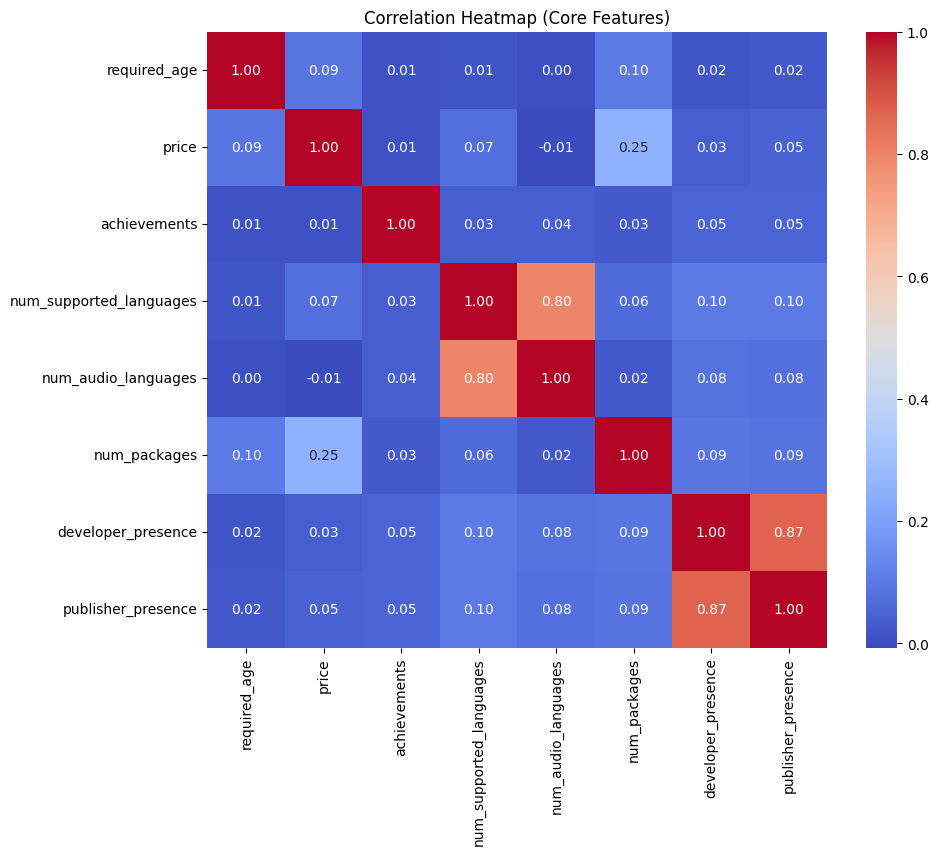

In [46]:
core_cols = [
    'required_age',
    'price',
    'achievements',
    'num_supported_languages',
    'num_audio_languages',
    'num_packages',
    'developer_presence',
    'publisher_presence'
]

plt.figure(figsize=(10, 8))
sns.heatmap(fe_df[core_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Core Features)')
plt.show()

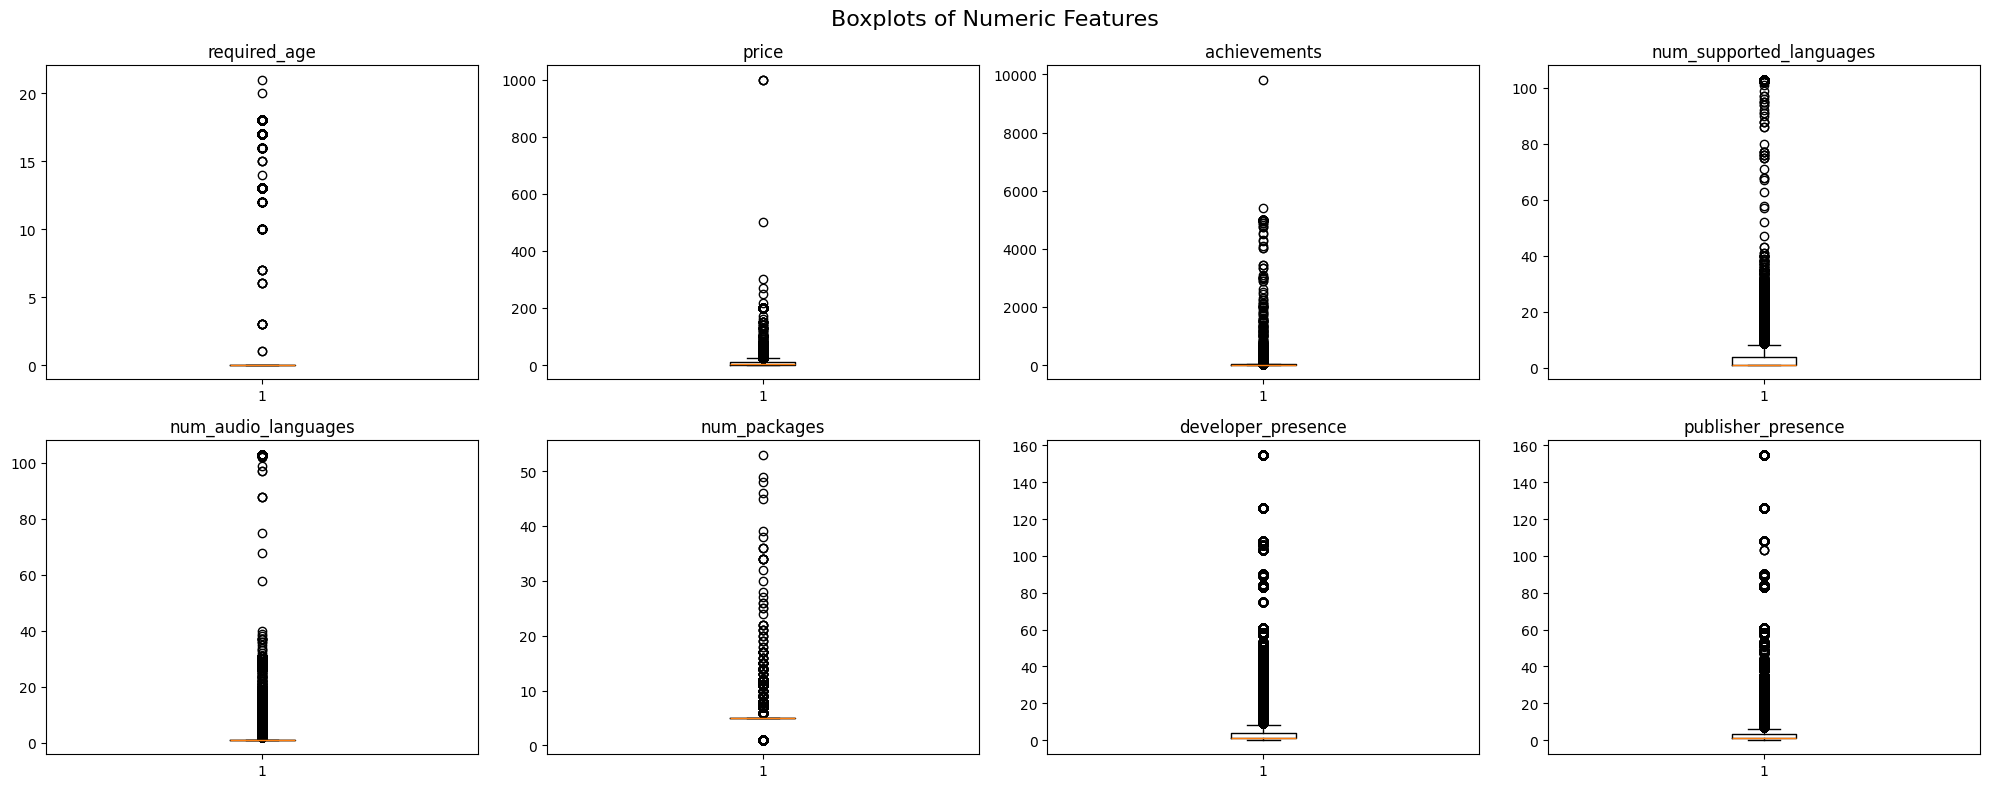

In [47]:
# plotting boxplots for numeric columns to check for outliers

num_cols = len(core_cols)
cols = 4
rows = math.ceil(num_cols / cols)

plt.figure(figsize=(20, rows * 4))

plt.suptitle('Boxplots of Numeric Features', fontsize=16)

for i, col in enumerate(core_cols):
    plt.subplot(rows, cols, i + 1)
    plt.boxplot(fe_df[col].dropna())
    plt.title(col)

plt.subplots_adjust(top=0.92)
plt.tight_layout()
plt.show()

In [48]:
cols_to_log = [
    'achievements',
    'num_supported_languages',
    'num_audio_languages',
    'developer_presence',
    'publisher_presence',
    'num_packages'
]

for col in cols_to_log:
    fe_df[f'log_{col}'] = np.log1p(fe_df[col])

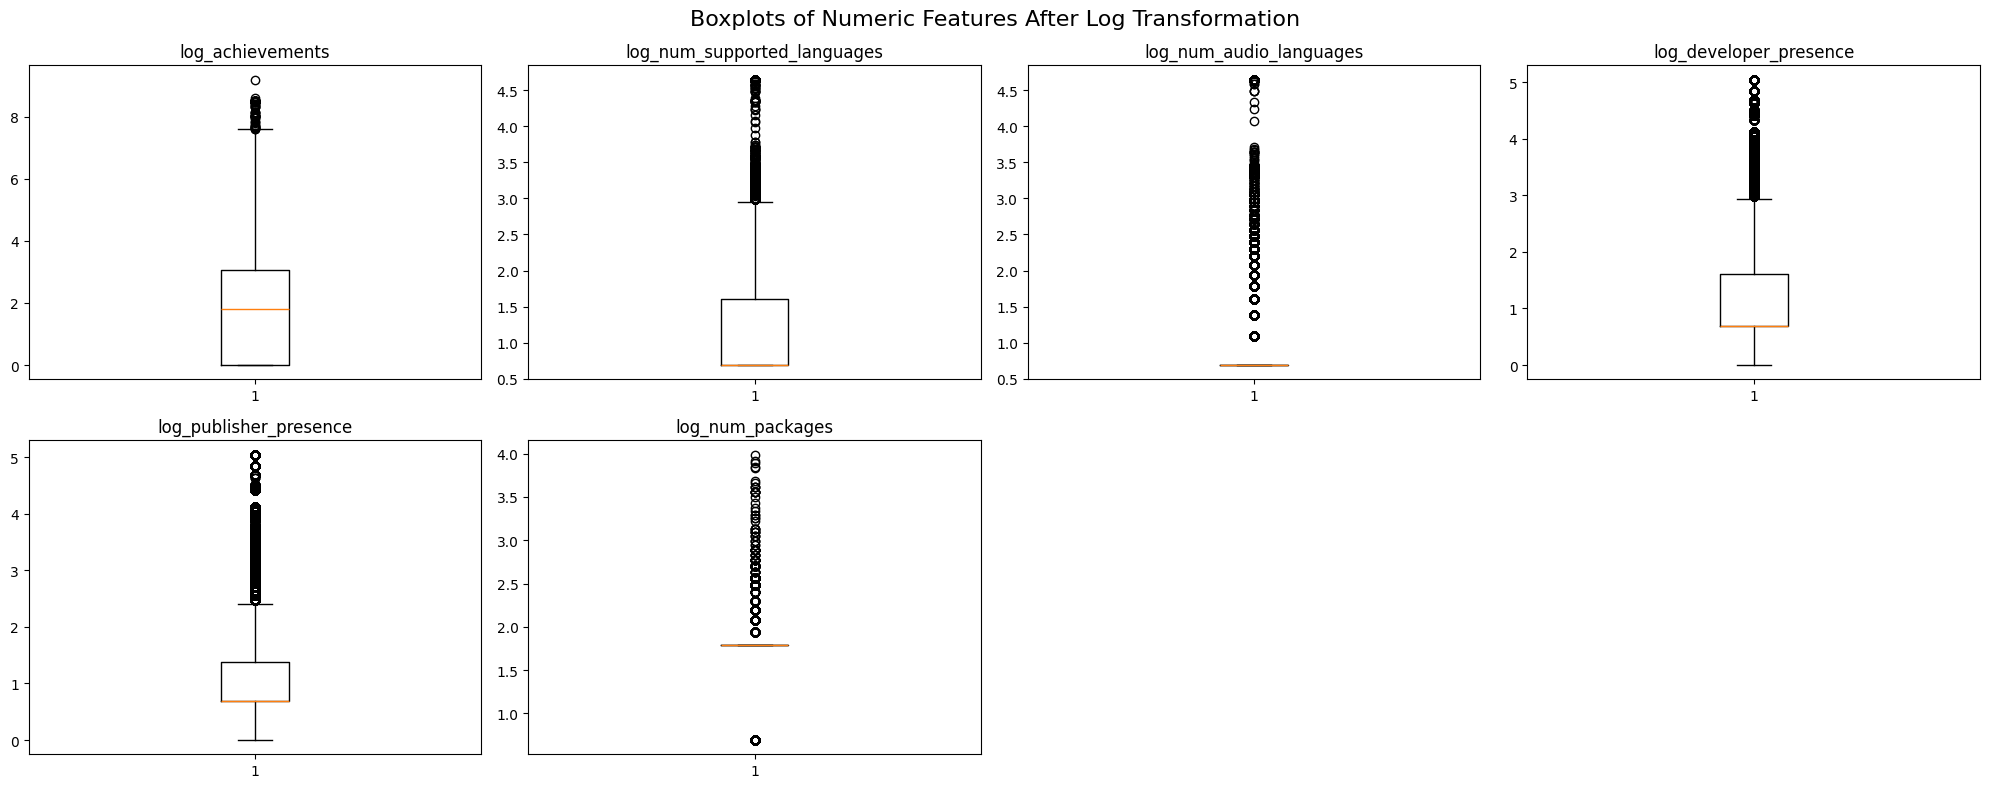

In [49]:
# plotting boxplots for numeric columns to check for outliers

log_cols = [col for col in fe_df.columns if col.startswith('log_')]
num_cols = len(log_cols)
cols = 4
rows = math.ceil(num_cols / cols)

plt.figure(figsize=(20, rows * 4))

plt.suptitle('Boxplots of Numeric Features After Log Transformation', fontsize=16)

for i, col in enumerate(log_cols):
    plt.subplot(rows, cols, i + 1)
    plt.boxplot(fe_df[col].dropna())
    plt.title(col)

plt.subplots_adjust(top=0.92)
plt.tight_layout()
plt.show()

### 📌 **IMPLEMENTATIONS**

* Computed a **correlation matrix (core numerical features)** to evaluate multicollinearity.

  * No strong multicollinearity detected.
  * `num_supported_languages` and `num_audio_languages` show **moderate correlation (~0.80)**, retained due to their meaningful domain relationship.

* Visualized feature distributions using **boxplots**, identifying **significant right-skewness** and presence of extreme outliers across multiple variables.

* Applied **log transformation (`log1p`)** to mitigate skewness and stabilize variance.

  * Transformation applied to:

    * `achievements`
    * `num_supported_languages`
    * `num_audio_languages`
    * `num_packages`
    * `developer_presence`
    * `publisher_presence`
  * Excluded:

    * `required_age` → categorical-like feature
    * `price` → target variable
    * `is_free` → binary target

* Re-evaluated distributions post-transformation using boxplots, confirming:

  * Reduced skewness
  * Compression of extreme outliers
  * Improved feature scaling for modeling

---

In [50]:
# exporting the cleaned and feature engineered DataFrame to a new CSV file for future use in modeling and analysis.
fe_df.to_csv('../data/processed/games_march2025_fe.csv', index=False)

## 📌 **CONCLUSION – DATA PREPROCESSING AND FEATURE ENGINEERING**

This phase focused on transforming the raw Steam dataset into a **clean, structured, and model-ready format**, using only **pre-release predictive signals**.

### 🔑 Key Outcomes

* Removed **irrelevant, high-null, and post-release features** (reviews, playtime, engagement metrics) to eliminate noise and prevent data leakage.

* Handled missing and placeholder values (e.g., normalized `required_age`).

* Engineered meaningful features, including:

  * `is_free` *(Stage 1 target)*
  * `release_year`
  * Language-based features
  * `num_packages`
  * `developer_presence` and `publisher_presence`
  * `top_developer` and `top_publisher`
  * `price_category` *(Stage 2 target)*

* Transformed high-cardinality categorical features into structured numerical representations:

  * **Genres** → top-N multi-label features capturing core game types
  * **Tags** → top-K high-signal features representing gameplay characteristics (with leakage terms removed)
  * **Categories** → selected binary indicators for gameplay modes (e.g., multiplayer, co-op, PvP)

* Converted developer and publisher data into **frequency-based signals**, capturing studio influence without sparse encoding.

* Performed **correlation analysis on core numerical features**, confirming no critical multicollinearity.

* Addressed heavy skewness in numerical features using **log transformation (`log1p`)**, improving distribution stability and scaling.

* Reduced and structured the dataset while simultaneously **enhancing feature richness through controlled categorical expansion**.

---

### 🧠 **Final Outcome**

The dataset is now fully prepared for modeling, combining:

* **Structural features** (age, languages, packages)
* **Behavioral signals** (developer/publisher strength)
* **Semantic features** (genres, tags, categories)

This creates a well-balanced feature space aligned with the project’s **two-stage prediction framework**:

* **Stage 1** → Free vs Paid
* **Stage 2** → Price Tier Prediction (for paid games)

---

### ✅ **PHASE 02 – DATA PREPROCESSING AND FEATURE ENGINEERING COMPLETED**

➡ Moving to **Phase 03 – Stage 1: Binary Classification (Free vs Paid)**

---
